In [1]:
%pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 110.6 MB/s eta 0:00:0000:01:01


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Layer, Concatenate
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping

import torch
import torch.nn as nn
import torch.nn.functional as F

import gurobipy as gp
from gurobipy import GRB

# Optional: torch_geometric for graph layers
try:
    from torch_geometric.nn import GATConv
    from torch_geometric.data import Data as GeoData
except Exception:
    GATConv = None
    GeoData = None


# Data Prep


In [ ]:
data_23_24 = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fantasyGo_FPL.csv')
fg_managers = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fgo_managers.csv')
 #('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/FantasyGo/FPL%20predictors/with%20new%20features/data/joint/23-24/merged_player_data.csv')

data_24_25 =

In [5]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'score', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'score_bps_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'score_bps_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'score_bps_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'score_bps_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'score_bps_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]


cols = [ 'position',  'creativity','ict_index', 'influence','selected',  'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home',
        'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'round', 'team', 'opponent_team','fpl_name', 'xP',


        'opponent_xgc_3', 'opponent_xgc_5', 'opponent_gc_3', 'opponent_gc_5', 'opponent_goals_scored_3', 'opponent_goals_scored_5', 'team_was_home', 'opponent_ict', 'opponent_xG',
        'opponent_xA', 'opponent_goals_scored', 'opponent_shots', 'opponent_npxG', 'opponent_value', 'opponent_whh', 'opponent_whd', 'opponent_wha', 'opponent_difficulty',

        'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
        'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
        'team_a_score_1', 'team_h_score_1', 'score_bps_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1',  'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',
        'xP_1',

        'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
        'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
        'team_a_score_3', 'team_h_score_3', 'score_bps_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3',  'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',
        'xP_3',

        'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
        'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
        'team_a_score_5', 'team_h_score_5', 'score_bps_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5',  'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',
        'xP_5',

        ]


In [6]:
play_data = data_23_24.copy()


play_data['gw'] = play_data['round']
play_data['team'] = play_data['player_team']
play_data['opponent_team'] = play_data.apply(lambda row: row['a_team'] if row['was_home'] == 1 else row['h_team'], axis=1)
play_data[['h_team', 'a_team', 'was_home', 'team', 'opponent_team', 'player_team', 'gw', 'round']]


sum_features = [
    'creativity', 'influence', 'threat',
    'expected_goals_1', 'expected_assists_1', 'expected_goal_involvements_1',
    'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1',
    'shots_1', 'key_passes_1', 'npg_1', 'npxG_1',
]

mean_features = [
    'value', 'ict_index', 'selected', 'transfers_in', 'transfers_out'
]

# max_features = [
#     'minutes_1', 'influence'
# ]

identity_features = [
    'whh', 'whd', 'wha',    # bookmaker odds
    'was_home',
    'opponent_team'
]

team_df = play_data.groupby(['team', 'gw']).agg({
    **{f: 'sum' for f in sum_features},
    **{f: 'mean' for f in mean_features},
    # **{f: 'max' for f in max_features},
    **{f: 'first' for f in identity_features}
}).reset_index()

for col in ['expected_goals_conceded_1','goals_conceded_1','goals_scored_1']:
    team_df[f'{col}_3'] = team_df.groupby('team')[col].rolling(3, min_periods=1).mean().reset_index(0, drop=True)
    team_df[f'{col}_5'] = team_df.groupby('team')[col].rolling(5, min_periods=1).mean().reset_index(0, drop=True)


team_df = team_df.rename(columns={
    'creativity': 'team_creativity',
    'influence': 'team_influence',
    'threat': 'team_threat',
    'expected_goals_1': 'team_expected_goals',
    'expected_assists_1': 'team_expected_assists',
    'expected_goal_involvements_1': 'team_expected_goal_involvements',
    'expected_goals_conceded_1': 'team_expected_goals_conceded',
    'goals_conceded_1': 'team_goals_conceded',
    'goals_scored_1': 'team_goals_scored',
    'shots_1': 'team_shots',
    'attempted_passes_1': 'team_attempted_passes',
    'key_passes_1': 'team_key_passes',
    'npg_1': 'team_npg',
    'npxG_1': 'team_npxG',
    'value': 'team_value',
    'ict_index': 'team_ict_index',
    'selected': 'team_selected',
    'transfers_in': 'team_transfers_in',
    'transfers_out': 'team_transfers_out',
    'whh': 'team_whh',
    'whd': 'team_whd',
    'wha': 'team_wha',
    'was_home': 'team_was_home',
    'expected_goals_conceded_1_3': 'team_expected_goals_conceded_3',
    'expected_goals_conceded_1_5': 'team_expected_goals_conceded_5',
    'goals_conceded_1_3': 'team_goals_conceded_3',
    'goals_conceded_1_5': 'team_goals_conceded_5',
    'goals_scored_1_3': 'team_goals_scored_3',
    'goals_scored_1_5': 'team_goals_scored_5',

    })


team_df = team_df.rename(columns={
    'creativity': 'team_creativity',
    'influence': 'team_influence',
    'threat': 'team_threat',
    'expected_goals_1': 'team_expected_goals',
    'expected_assists_1': 'team_expected_assists',
    'expected_goal_involvements_1': 'team_expected_goal_involvements',
    'expected_goals_conceded_1': 'team_expected_goals_conceded',
    'goals_conceded_1': 'team_goals_conceded',
    'goals_scored_1': 'team_goals_scored',
    'shots_1': 'team_shots',
    'attempted_passes_1': 'team_attempted_passes',
    'key_passes_1': 'team_key_passes',
    'npg_1': 'team_npg',
    'npxG_1': 'team_npxG',
    'value': 'team_value',
    'ict_index': 'team_ict_index',
    'selected': 'team_selected',
    'transfers_in': 'team_transfers_in',
    'transfers_out': 'team_transfers_out',
    'whh': 'team_whh',
    'whd': 'team_whd',
    'wha': 'team_wha',
    'was_home': 'team_was_home',
    'expected_goals_conceded_1_3': 'team_expected_goals_conceded_3',
    'expected_goals_conceded_1_5': 'team_expected_goals_conceded_5',
    'goals_conceded_1_3': 'team_goals_conceded_3',
    'goals_conceded_1_5': 'team_goals_conceded_5',
    'goals_scored_1_3': 'team_goals_scored_3',
    'goals_scored_1_5': 'team_goals_scored_5',

    })

opponent_stats = team_df[['team', 'gw','team_ict_index', 'team_expected_goals', 'team_expected_assists', 'team_goals_scored', 'team_shots', 'team_npxG', 'team_value',
                          'team_whh', 'team_whd', 'team_wha', 'team_expected_goals_conceded_3', 'team_expected_goals_conceded_5', 'team_goals_conceded_3', 'team_goals_conceded_5',
                          'team_goals_scored_3', 'team_goals_scored_5']].rename(

                columns={'team': 'opponent_team', 'team_ict_index':'opponent_ict','team_expected_goals': 'opponent_xG', 'team_expected_assists': 'opponent_xA',
                        'team_goals_scored': 'opponent_goals_scored', 'team_shots': 'opponent_shots', 'team_npxG': 'opponent_npxG', 'team_value': 'opponent_value',
                        'team_whh': 'opponent_whh', 'team_whd': 'opponent_whd', 'team_wha': 'opponent_wha', 'team_expected_goals_conceded_3': 'opponent_xgc_3',
                        'team_expected_goals_conceded_5': 'opponent_xgc_5', 'team_goals_conceded_3': 'opponent_gc_3', 'team_goals_conceded_5': 'opponent_gc_5',
                        'team_goals_scored_3': 'opponent_goals_scored_3', 'team_goals_scored_5': 'opponent_goals_scored_5'
                        })

# opponent_stats
# 2. Merge this back into the original dataframe matching on 'opponent_team' and 'gw'
team_df = team_df.merge(opponent_stats, on=['opponent_team', 'gw'], how='left')

final_df = play_data.merge(team_df, on=['opponent_team', 'team','gw'], how='left')

# ODI = Probability of Draw + Probability of Away Win (assuming player's team is Home odds)
# A high ODI means a tough fixture (Player's team is less likely to win).
# ODI = Probability of Draw + Probability of Home Win (assuming player's team is Away odds)
# A high ODI means a tough fixture (Player's team is more likely to win).
final_df['opponent_difficulty'] = final_df.apply(
    lambda row: (row['whd'] + row['wha'])
    if row['player_team'] == row['h_team']
    else (row['whd'] + row['whh']),
    axis=1
)

final_df['team_difficulty'] = final_df.apply(
    lambda row: (row['whd'] + row['wha'])
    if row['player_team'] == row['a_team']
    else (row['whd'] + row['whh']),
    axis=1
)

final_df['team_difficulty']


,team_difficulty
0,0.604
1,0.894
2,0.894
3,0.894
4,0.894
...,...
4921,0.674
4922,0.124
4923,0.183
4924,0.347


In [7]:
data_23_24[['score', 'score_bps_1', 'score_bps_3', 'score_bps_5']]

,score,score_bps_1,score_bps_3,score_bps_5
0,2.0,NaN,NaN,NaN
1,1.0,NaN,NaN,NaN
2,12.0,NaN,NaN,NaN
3,7.0,NaN,NaN,NaN
4,5.0,NaN,NaN,NaN
...,...,...,...,...
4921,2.0,0.0,3.33,2.6
4922,1.0,2.0,0.67,0.6
4923,1.0,1.0,1.00,1.0
4924,1.0,0.0,2.00,1.2


# Functions


### Predictors


In [25]:
# --- Step 1: Data Preparation Function ---

def prepare_fpl_data(data, cols):
    """
    Prepares features (X), conditional parameters (M), targets (Y),
    and gameweeks (GW) for the AffinePNN model.
    """
    cols_ = list(cols)
    if 'team_difficulty' not in cols_:
        cols_.append('team_difficulty')

    data_ = data[cols_].copy()

    # Target and metadata columns
    target_col = ['xP', 'fpl_name']
    gameweek_col = 'round'
    POSITION_COL = 'position'
    M_COLS = ['opponent_difficulty' , 'team_difficulty' , 'was_home'] #, 'whh', 'whd', 'wha'

    # Handle Categorical Features
    CATEGORICAL_COLS = [POSITION_COL, 'team', 'opponent_team']
    df = pd.get_dummies(data_, columns=CATEGORICAL_COLS, prefix=CATEGORICAL_COLS, dummy_na=False)

    # 2. Target Variable (Y)
    Y = df[target_col].fillna(0)

    # 3. Input Features (X)
    EXCLUDE_COLS = [*target_col, gameweek_col, *M_COLS]

    # Find position-related columns for explicit inclusion if needed
    new_position_cols = [col for col in df.columns if col.startswith(f'{POSITION_COL}_')]

    # Filter feature columns
    X_cols = [c for c in df.columns if c not in EXCLUDE_COLS and c != POSITION_COL]

    # Final check of column existence
    X_cols = [col for col in X_cols if col in df.columns]

    # Convert to numpy
    X = df[X_cols].fillna(0).values.astype(np.float32)
    M = df[M_COLS].fillna(0).values.astype(np.float32)
    GW = df[gameweek_col].values

    print(f"Data prepared. X shape: {X.shape}, M shape: {M.shape}, Y shape: {Y.shape}")
    return X, M, Y, GW, X_cols


def transform_data(final_df, cols, gw):
    # Prepare data
    X_full, M_full, Y_full, GW_full, X_cols = prepare_fpl_data(final_df, cols)

    # Split
    GW_TRAIN_END = gw - 1
    train_mask = GW_full <= GW_TRAIN_END
    test_mask = GW_full == (GW_TRAIN_END + 1)

    X_train, M_train, Y_train_raw = X_full[train_mask], M_full[train_mask], Y_full[train_mask]
    X_test, M_test, Y_test_raw = X_full[test_mask], M_full[test_mask], Y_full[test_mask]

    Y_train = Y_train_raw['xP'].values
    Y_test = Y_test_raw['xP'].values
    Y_test_names = Y_test_raw['fpl_name'].values

    # Scaling
    scaler_x = StandardScaler()
    X_train_scaled = scaler_x.fit_transform(X_train)
    X_test_scaled = scaler_x.transform(X_test)

    scaler_m = StandardScaler()
    M_train_scaled = scaler_m.fit_transform(M_train)
    M_test_scaled = scaler_m.transform(M_test)
    return (X_train_scaled, M_train_scaled, train_mask, Y_train), (X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names), GW_full, X_cols


# --- Step 2: Custom Affine Conditioning Layer ---

class AffineConditioning(Layer):
    """
    Custom Keras Layer implementing the core Affine Parametric Neural Network (AffinePNN) logic.
    z = (phi * m + s0) * x + (psi * m + b0)
    """
    def __init__(self, units, activation=None, **kwargs):
        super(AffineConditioning, self).__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        # input_shape: [feature_input_shape, parameter_input_shape]
        feature_dim = input_shape[0][-1]
        param_dim = input_shape[1][-1]

        # Weights to transform the parameter 'm' into scale and bias adjustments
        # Shape is (param_dim, feature_dim) to map conditions to feature space
        self.phi = self.add_weight(shape=(param_dim, feature_dim),
                                   initializer='glorot_uniform', trainable=True, name='phi')
        self.psi = self.add_weight(shape=(param_dim, feature_dim),
                                   initializer='glorot_uniform', trainable=True, name='psi')

        # Base scaling and bias
        self.s0 = self.add_weight(shape=(feature_dim,), initializer='ones', trainable=True, name='s0')
        self.b0 = self.add_weight(shape=(feature_dim,), initializer='zeros', trainable=True, name='b0')

        self.built = True

    def call(self, inputs):
        x_in, m = inputs # x_in: (batch, feat), m: (batch, cond)

        # Calculate scale and bias based on conditional input m
        # (batch, cond) @ (cond, feat) -> (batch, feat)
        s_m = tf.matmul(m, self.phi)
        b_m = tf.matmul(m, self.psi)

        s = s_m + self.s0
        b = b_m + self.b0

        # Apply affine transformation
        x_out = s * x_in + b

        if self.activation is not None:
            return self.activation(x_out)
        return x_out

    def get_config(self):
        config = super(AffineConditioning, self).get_config()
        config.update({
            'units': self.units,
            'activation': tf.keras.activations.serialize(self.activation),
        })
        return config

# --- Step 3: Model Architecture ---

def build_affine_pnn(input_dim_x, input_dim_m, output_dim_y, hidden_units=128):
    """
    Builds the Affine Parametric Neural Network (AffinePNN) Model.
    """
    L2_REG = 0.001

    X_input = Input(shape=(input_dim_x,), name='X_input')
    M_input = Input(shape=(input_dim_m,), name='M_input')

    # Initial Dense Layer
    x = Dense(hidden_units, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(L2_REG), name='Dense_1')(X_input)

    # Affine Conditioning Block 1
    x = AffineConditioning(units=hidden_units, activation='relu', name='Affine_Cond_1')([x, M_input])

    # Standard Dense Layer
    x = Dense(hidden_units // 2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(L2_REG), name='Dense_2')(x)

    # Affine Conditioning Block 2
    x = AffineConditioning(units=hidden_units // 2, activation='relu', name='Affine_Cond_2')([x, M_input])

    # Final Prediction Layer
    output = Dense(output_dim_y, activation='linear', name='Output')(x)

    model = Model(inputs=[X_input, M_input], outputs=output, name='AffinePNN_FPL')
    return model

def plot_training_history(history):
    """
    Plots the training and validation loss/metrics including MSE.
    """
    metrics = ['loss', 'mae', 'mse']
    plt.figure(figsize=(18, 5))

    for i, metric in enumerate(metrics):
        plt.subplot(1, 3, i + 1)
        plt.plot(history.history[metric], label='Train')
        plt.plot(history.history[f'val_{metric}'], label='Validation')
        plt.title(f'Model {metric.upper()}')
        plt.xlabel('Epoch')
        plt.ylabel(metric.upper())
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


def evaluator(model, X_test_scaled, M_test_scaled, Y_test):
    # 1. EVALUATE TEST SET PERFORMANCE using model.evaluate
    print("\nEvaluating test set performance...")
    test_results = model.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

    # Generate predictions to calculate R2 score manually
    Y_pred = model.predict([X_test_scaled, M_test_scaled]).flatten()
    r2 = r2_score(Y_test, Y_pred)

    evaluation_metrics = {
        'test_loss': test_results['loss'],
        'test_mae': test_results['mae'],
        'test_mse': test_results['mse'],
        'test_R2': r2
    }


    return evaluation_metrics



### Optimizers


#### IRL for HEPs


In [18]:
def greedy_expert_strategy(players, hist_xp=None, K=15, max_team_ratio=3, corr_threshold=0.8):
    """
    Greedy selection that picks top xP_pred players while respecting
    team (club) caps and avoiding players highly correlated in historical xP.
    Returns a binary selection vector for the N players.
    (Paper: Heuristic-Guided Inverse RL -> Expert Trajectory Generation)
    """
    N = len(players)
    # Prioritize higher predicted points
    order = players.sort_values('xP_pred', ascending=False).index.tolist()
    selected = []
    team_counts = {}

    # Compute correlation matrix if hist_xp provided
    corr = None
    if hist_xp is not None:
        try:
            # Use Pearson correlation (linear relationship)
            corr = np.corrcoef(hist_xp, rowvar=False)
            corr = np.nan_to_num(corr)
        except Exception:
            corr = None

    for idx in order:
        if len(selected) >= K:
            break

        # Check FPL Club Constraint (Heuristic Rule 1)
        team = players.loc[idx, 'team']
        if team_counts.get(team, 0) >= max_team_ratio:
            continue

        # Check Correlation Constraint (Heuristic Rule 2: Correlation Control)
        if corr is not None and len(selected) > 0:
            # Calculate average positive correlation with already selected players
            selected_indices = [players.index.get_loc(s) for s in selected]
            player_idx = players.index.get_loc(idx)

            # Avg positive correlation with selected players
            correlations = [corr[player_idx, s_idx] for s_idx in selected_indices if corr[player_idx, s_idx] > 0]
            if correlations and np.mean(correlations) >= corr_threshold:
                continue

        selected.append(players.loc[idx, 'player_id'])
        team_counts[team] = team_counts.get(team, 0) + 1

    # Return selection vector based on original index (player_id)
    sel_vec = np.zeros(N, dtype=int)
    for p_id in selected:
        sel_vec[p_id] = 1
    return sel_vec

class RewardNetwork(nn.Module):
    """
    Simple reward network that combines features to produce scalar reward.
    (Paper: Multi-Objective Reward Learning)
    """
    def __init__(self, in_dim):
        super().__init__()
        # Simulates the combination of base features (return) and induced features (correlation/diversity)
        self.base = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64,32), nn.ReLU())
        self.ind_layer = nn.Sequential(nn.Linear(in_dim,32), nn.ReLU())
        self.out = nn.Linear(32+32, 1)

    def forward(self, x):
        b = self.base(x)
        i = self.ind_layer(x)
        concat = torch.cat([b,i], dim=-1)
        r = self.out(concat).squeeze(-1)
        return r

# -------------------------------------------------------------------------
# 3. REWARD LEARNING (MAXENT IRL)
# -------------------------------------------------------------------------

class RewardNetwork(nn.Module):
    """
    Simple reward network that combines features to produce scalar reward.
    (Paper: Multi-Objective Reward Learning)
    """
    def __init__(self, in_dim):
        super().__init__()
        # Simulates the combination of base features (return) and induced features (correlation/diversity)
        self.base = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64,32), nn.ReLU())
        self.ind_layer = nn.Sequential(nn.Linear(in_dim,32), nn.ReLU())
        self.out = nn.Linear(32+32, 1)

    def forward(self, x):
        b = self.base(x)
        i = self.ind_layer(x)
        concat = torch.cat([b,i], dim=-1)
        r = self.out(concat).squeeze(-1)
        return r

def maxent_irl_train(players, expert_sel_vec, epochs=200, lr=5e-3, device='cpu'):
    """
    Fits RewardNetwork to assign higher reward to expert-selected players.
    (Paper: Maximum Entropy Inverse Reinforcement Learning)
    """
    # Features: price, xP_pred, one-hot position (Simulating state representation)
    pos_map = {'GK':0,'DEF':1,'MID':2,'FWD':3}
    pos_onehot = np.zeros((len(players),4))
    for i,p in players.iterrows():
        pos_onehot[i, pos_map[p['position']]] = 1

    X = np.concatenate([players[['price','xP_pred']].values, pos_onehot], axis=1)
    X = torch.tensor(X, dtype=torch.float32, device=device)

    net = RewardNetwork(in_dim=X.shape[1]).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)

    expert_mask = torch.tensor(expert_sel_vec, dtype=torch.float32, device=device)

    for ep in range(epochs):
        opt.zero_grad()
        r = net(X)  # Learned reward per player

        # MaxEntIRL loss (simplified): Encourages high reward for expert moves
        # while keeping the reward landscape smooth (entropy maximization).
        # Maximizing E_expert[R] equivalent to Minimizing -E_expert[R]

        # Safe division
        expert_sum = expert_mask.sum()
        if expert_sum == 0:
            expert_term = 0
        else:
            expert_term = (r * expert_mask).sum() / expert_sum

        loss = - expert_term
        loss += torch.logsumexp(r, dim=0) * 0.01             # Regularization (E_agent[e^R])

        loss.backward()
        opt.step()

        if (ep+1) % 50 == 0:
            print(f"IRL epoch {ep+1}/{epochs} loss={loss.item():.4f}")

    with torch.no_grad():
        learned_r = net(X).cpu().numpy()
        # Normalize learned reward to be positive and add to player table
        ptp = np.ptp(learned_r)
        if ptp == 0: ptp = 1e-8
        learned_r = (learned_r - learned_r.min()) / ptp
        players['learned_r'] = learned_r

    return net, players

# ---------------------- Simplified MaxEnt IRL training -------------------

def maxent_irl_train(players, expert_sel_vec, epochs=200, lr=5e-3, device='cpu'):
    """
    Fits RewardNetwork to assign higher reward to expert-selected players.
    (Paper: Maximum Entropy Inverse Reinforcement Learning)
    """
    # Features: price, xP_pred, one-hot position (Simulating state representation)
    pos_map = {'GK':0,'DEF':1,'MID':2,'FWD':3}
    pos_onehot = np.zeros((len(players),4))
    for i,p in players.iterrows():
        pos_onehot[i, pos_map[p['position']]] = 1

    X = np.concatenate([players[['price','xP_pred']].values, pos_onehot], axis=1)
    X = torch.tensor(X, dtype=torch.float32, device=device)

    net = RewardNetwork(in_dim=X.shape[1]).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)

    expert_mask = torch.tensor(expert_sel_vec, dtype=torch.float32, device=device)

    for ep in range(epochs):
        opt.zero_grad()
        r = net(X)  # Learned reward per player

        # MaxEntIRL loss (simplified): Encourages high reward for expert moves
        # while keeping the reward landscape smooth (entropy maximization).
        loss = - (r * expert_mask).sum() / expert_mask.sum()  # Maximize E_expert[R]
        loss += torch.logsumexp(r, dim=0) * 0.01             # Regularization (E_agent[e^R])

        loss.backward()
        opt.step()
        if (ep+1) % 50 == 0:
            print(f"IRL epoch {ep+1}/{epochs} loss={loss.item():.4f}")

    with torch.no_grad():
        learned_r = net(X).cpu().numpy()
        # Normalize learned reward to be positive and add to player table
        # learned_r.ptp()
        learned_r = (learned_r - learned_r.min()) / (np.ptp(learned_r) + 1e-8)
        players['learned_r'] = learned_r

    return net, players

# ---------------------- Heterogeneous Graph Attention -------------------

class HGATPolicy(nn.Module):
    """
    A small HGAT that uses GATConv (if available) to produce player embeddings.
    (Paper: Heterogeneous Graph Policy Learning)
    """
    def __init__(self, in_dim, out_dim=32, heads=4):
        super().__init__()
        if GATConv is None:
            # fallback: MLP
            self.fallback = True
            self.mlp = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64, out_dim))
        else:
            self.fallback = False
            self.conv1 = GATConv(in_dim, 32, heads=heads, concat=True)
            self.conv2 = GATConv(32*heads, out_dim, heads=1, concat=False)

    def forward(self, x, edge_index=None):
        if self.fallback:
            return self.mlp(x)
        else:
            # Here, the HGAT would combine information from correlation graphs and team graphs.
            h = F.elu(self.conv1(x, edge_index))
            h = self.conv2(h, edge_index)
            return h

def ilp_select_squad(players, combined_score, budget=100.0, max_budget_per_pos=None):
    """
    Use Gurobi to select the optimal 11-man starting team and the captain.

    (Paper: Final Portfolio Optimization via Policy Output)
    """
    N = len(players)
    m = gp.Model("FPL_11_Man_Squad")
    m.Params.OutputFlag = 0 # Suppress Gurobi output

    # Decision Variables
    # x represents the 11 selected players (now the only selection variable)
    x = m.addVars(N, vtype=GRB.BINARY, name="x_selected")
    # z represents the Captain selection (1 player)
    z = m.addVars(N, vtype=GRB.BINARY, name="z_captain")

    # ------------------ OBJECTIVE FUNCTION ------------------
    # Maximize total score: Sum of (Selected Player Score) + (Captain Score Bonus)
    total_score = gp.quicksum(combined_score[i] * x[i] for i in range(N))
    captain_bonus = gp.quicksum(combined_score[i] * z[i] for i in range(N))
    m.setObjective(total_score + captain_bonus, GRB.MAXIMIZE)

    # ------------------ CONSTRAINTS ------------------

    # C1: Total size must be exactly 11 players
    m.addConstr(gp.quicksum(x[i] for i in range(N)) == 11, "Squad_Size_11")

    # C2: Budget constraint for the 11-man squad
    # Note: The budget is now used entirely for the 11 players.
    m.addConstr(gp.quicksum(players.loc[i,'price'] * x[i] for i in range(N)) <= budget, "Budget_Constraint")

    # C3: Club max 3 players in the 11-man squad
    clubs = players['team'].unique()
    for team in clubs:
        m.addConstr(gp.quicksum(x[i] for i in range(N) if players.loc[i,'team']==team) <= 3, f"Club_Limit_{team}")

    # C4: Captain selection (exactly 1 player)
    m.addConstr(gp.quicksum(z[i] for i in range(N)) == 1, "Captain_Select_1")

    # C5: Link between Captain and Selection: The captain must be one of the 11 selected players
    m.addConstrs((z[i] <= x[i] for i in range(N)), name="Captain_is_Selected")

    # C6: Formation constraint (Position limits for the 11 players)
    # Min/Max rules for the starting 11: 1 GK, 3-5 DEF, 2-5 MID, 1-3 FWD
    formation_limits = {
        "GK": (1, 1), # Exactly 1 GK must start
        "DEF": (3, 5),
        "MID": (2, 5),
        "FWD": (1, 3)
    }
    for pos, (min_req, max_req) in formation_limits.items():
        pos_selected = gp.quicksum(x[i] for i in range(N) if players.loc[i,'position']==pos)
        m.addConstr(pos_selected >= min_req, f"Selection_Min_{pos}")
        m.addConstr(pos_selected <= max_req, f"Selection_Max_{pos}")


    m.optimize()

    # Extract Results
    selected_ids = []
    captain_id = -1

    if m.status == GRB.OPTIMAL:
        for i in range(N):
            if x[i].X > 0.5:
                selected_ids.append(players.loc[i, 'player_id'])
            if z[i].X > 0.5:
                captain_id = players.loc[i, 'player_id']

    # Since we only selected 11, the "starter" list is the same as the "squad" list
    return selected_ids, selected_ids, captain_id

# ----------------------------- Putting it together -----------------------

def run_pipeline(players):
    """Main function to run the IRL-HGAT-ILP FPL optimization pipeline."""
    # Step 1: Data Generation
    # players, hist = make_dummy_players(n_players=90, seed=42)

    # players
    hist = None

    # Step 2: Generate Expert Strategy (Heuristic-Guided Trajectory)
    # Note: K=11 for the expert selection now, to match the final goal.
    expert_sel = greedy_expert_strategy(
        players,
        hist_xp=hist,
        K=11, # Changed to 11
        max_team_ratio=3,
        corr_threshold=0.85 # Tighter correlation constraint for the expert
    )
    print(f"Expert selected count (11-man heuristic): {expert_sel.sum()}")

    # Step 3: Train Simplified MaxEnt IRL (Multi-Objective Reward Learning)
    net, players = maxent_irl_train(players.copy(), expert_sel, epochs=200, lr=5e-3)

    # Step 4: HGAT Policy (Feature Embedding, simulates cross-player understanding)
    N = len(players)
    # Build graph edges based on club affiliation (Industry/Sector Graph in the paper)

    edge_idx = []
    for i in range(N):
        for j in range(i + 1, N):
            # print(i, j)
            if players.loc[i,'team'] == players.loc[j,'team']:
                # Bidirectional edge
                edge_idx.append([i, j])
                edge_idx.append([j, i])
    edge_index = torch.tensor(edge_idx, dtype=torch.long).t().contiguous() if edge_idx else None

    # Node features: price, xP_pred, learned_r, one-hot pos
    pos_map = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}
    pos_onehot = np.zeros((N, 4))
    for i, p in players.iterrows():
        pos_onehot[i, pos_map[p['position']]] = 1

    X = np.concatenate([
        players[['price', 'xP_pred', 'learned_r']].values,
        pos_onehot
    ], axis=1)
    X_t = torch.tensor(X, dtype=torch.float32)

    policy = HGATPolicy(in_dim=X.shape[1])
    with torch.no_grad():
        emb = policy(X_t, edge_index)
    print(f"HGAT Policy Embeddings Shape: {emb.shape}")

    # Step 5: Final ILP Optimization using Combined Score
    # We combine the "raw return" (xP_pred) with the "learned reward" (risk/diversity value)
    combined_score = (
        0.6 * players['xP_pred'].values +
        0.4 * players['learned_r'].values
    )

    # Note: The 'squad_sel_ids' and 'starter_sel_ids' are now identical (the 11 players)
    selected_ids, _, captain_id = ilp_select_squad(
        players,
        combined_score,
        budget=100.0 # Adjusted budget for a likely 11-man team
    )

    print("\n--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---")
    if selected_ids and len(selected_ids) == 11:
        squad_df = players[players['player_id'].isin(selected_ids)].copy()
        squad_df['Is_Captain'] = squad_df['player_id'] == captain_id

        # Calculate total score from the optimal selection
        total_xp_maximized = squad_df['xP_pred'].sum()
        captain_xp = squad_df[squad_df['Is_Captain']]['xP_pred'].iloc[0]
        total_xp_maximized += captain_xp # Add bonus points

        print(squad_df[['name','team','position','price','xP_pred', 'Is_Captain']].sort_values(by=['position', 'price'], ascending=[False, False]))
        print("\n--- SUMMARY ---")
        print(f"Total Team Cost: £{squad_df['price'].sum():.1f}m")
        print(f"Maximized Raw xP (11 Players + Captain Bonus): {total_xp_maximized:.2f} points")

        # Display Formation:
        formation = squad_df.groupby('position').size().to_dict()
        print(f"Formation Selected: {formation.get('DEF', 0)}-{formation.get('MID', 0)}-{formation.get('FWD', 0)}")
    else:
        print("No feasible solution found (or incorrect number of players selected).")

    return squad_df


# Models


## Predictors


## GW 36


### Predict


In [35]:
train_data, test_data , GW_full, X_cols = transform_data(final_df, cols, 36)
X_train_scaled, M_train_scaled, train_mask, Y_train = train_data
X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names = test_data

Data prepared. X shape: (4926, 177), M shape: (4926, 3), Y shape: (4926, 2)


In [36]:
# Model Setup
INPUT_DIM_X = X_train_scaled.shape[1]
INPUT_DIM_M = M_train_scaled.shape[1]
OUTPUT_DIM_Y = 1

model = build_affine_pnn(INPUT_DIM_X, INPUT_DIM_M, OUTPUT_DIM_Y)
model.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='mse', metrics=['mae', 'mse'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training
print("\nStarting Training...")
history = model.fit(
    [X_train_scaled, M_train_scaled], Y_train,
    epochs=10, # Increased epochs with early stopping
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Starting Training...
Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 9.8260 - mae: 2.3847 - mse: 9.5907 - val_loss: 4.0113 - val_mae: 1.4266 - val_mse: 3.7756
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.5886 - mae: 1.3682 - mse: 3.3529 - val_loss: 3.3112 - val_mae: 1.2693 - val_mse: 3.0758
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.8089 - mae: 1.1812 - mse: 2.5736 - val_loss: 3.0155 - val_mae: 1.1947 - val_mse: 2.7804
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.3633 - mae: 1.0791 - mse: 2.1282 - val_loss: 2.7968 - val_mae: 1.1372 - val_mse: 2.5619
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.1644 - mae: 1.0224 - mse: 1.9295 - val_loss: 2.7609 - val_mae: 1.1161 - val_mse: 2.5263
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.9832 - mae: 0.9667 - mse: 1.7487 - val_loss: 2.6559 - val_mae: 1.0909 - val_mse: 2.4215
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8888 - mae: 0.93

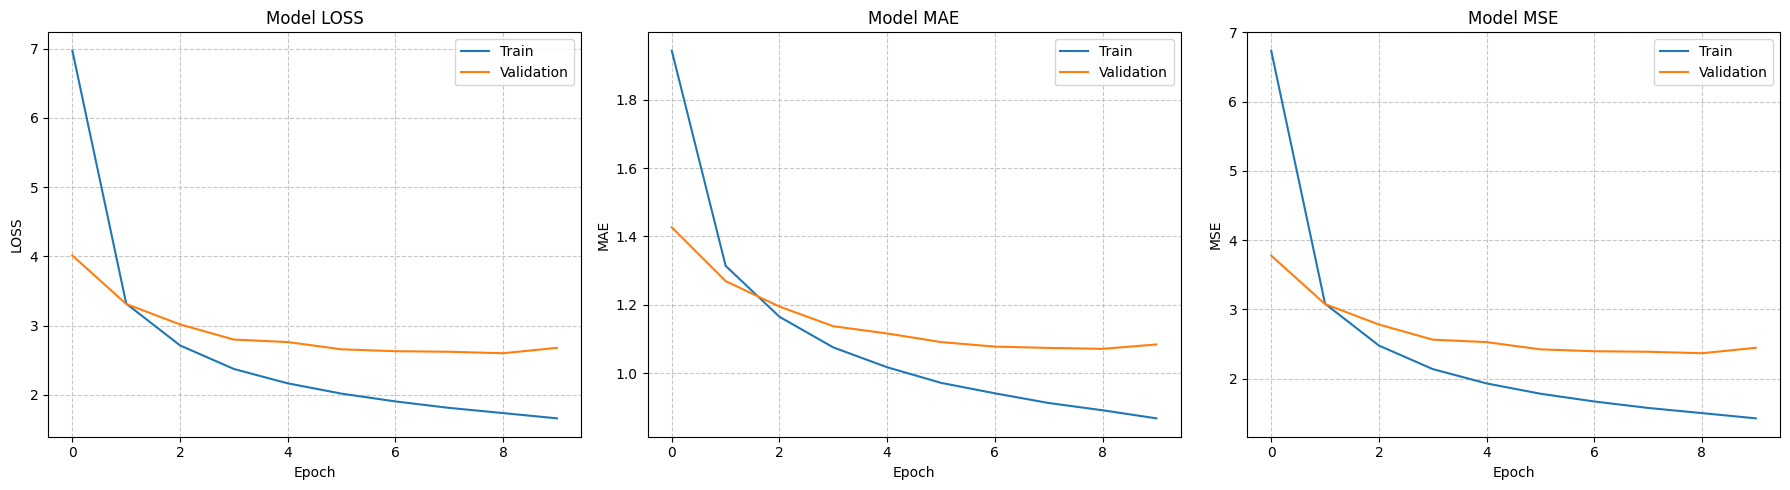


--- Final Test Set Evaluation (GW 37) ---

Evaluating test set performance...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Evaluating test set performance...{'loss': 1.904085397720337, 'mae': 0.9894630312919617, 'mse': 1.6705970764160156}
R²: 0.6818397415163333
MAE: 0.9894630312919617
MSE: 1.6705970764160156
Loss: 1.9040853977203369

Generating Predictions...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

--- Results for Gameweek 37 ---
 Gameweek          Player  Actual_xP  Predicted_xP  Team_Diff  Opp_Diff
       36     Cole Palmer        8.4         11.74       0.59      1.23
       36  Erling Haaland       10.0         11.74       1.52     -2.14
       36 Nicolas Jackson        8.0         11.46       0.59     -0.62
       36    Noni Madueke        6.6         10.90       0.59     -0.62
       36      Phil Foden        6.2         10.31       1.52     -2.14
       36  Anthony Gordon        9.0          9.02       0.22     -0.16
       36  Alexander Isak        9.0          8.81       0.22     -0.

In [37]:
# Plot History
plot_training_history(history)

# EVALUATE TEST SET PERFORMANCE
print("\n--- Final Test Set Evaluation (GW 37) ---")
test_results = model.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

evaluation_metrics = evaluator(model, X_test_scaled, M_test_scaled, Y_test)
print(f"Evaluating test set performance...{test_results}")
print(f"R²: {evaluation_metrics['test_R2']:.16f}")
print(f"MAE: {evaluation_metrics['test_mae']:.16f}")
print(f"MSE: {evaluation_metrics['test_mse']:.16f}")
print(f"Loss: {evaluation_metrics['test_loss']:.16f}")


# Prediction
print("\nGenerating Predictions...")
Y_pred = model.predict([X_test_scaled, M_test_scaled]).flatten()

# Results
results_df = pd.DataFrame({
    'Gameweek': GW_full[test_mask],
    'Player': Y_test_names,
    'Actual_xP': Y_test,
    'Predicted_xP': Y_pred,
    'Team_Diff': M_test_scaled[:, 1],
    'Opp_Diff': M_test_scaled[:, 0]
})

print("\n--- Results for Gameweek 37 ---")
print(results_df.sort_values(by='Predicted_xP', ascending=False).head(10).round(2).to_string(index=False))

#### Plots


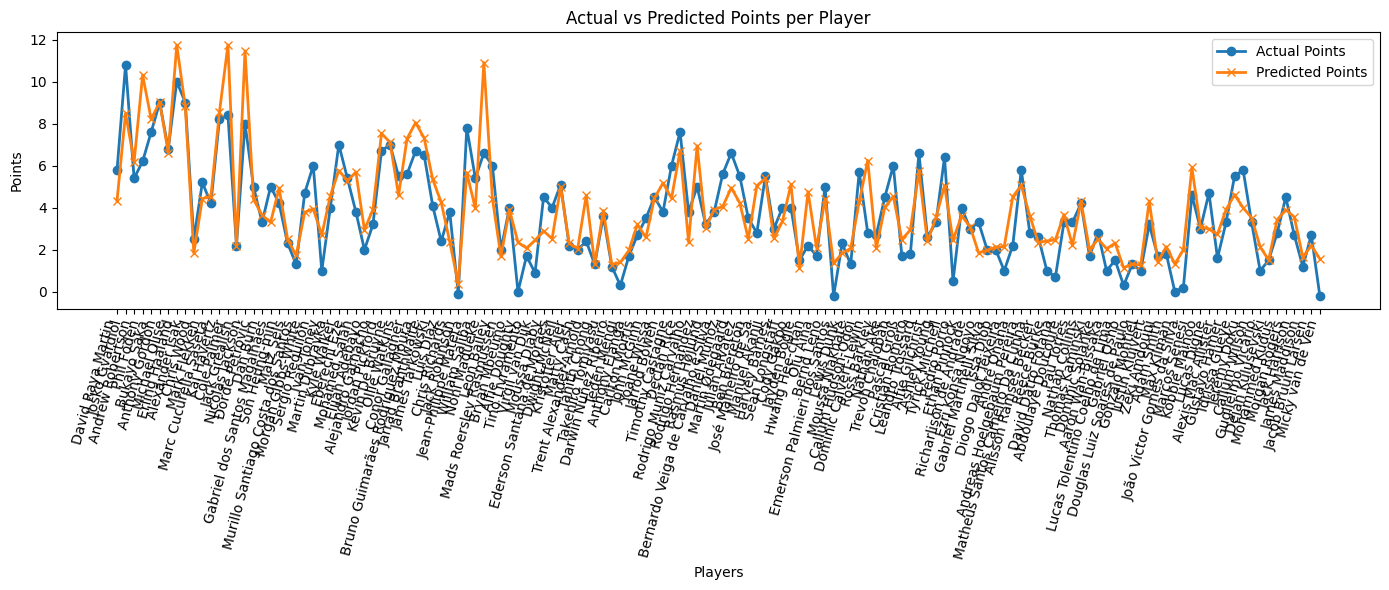

In [38]:
# Convert names to positions on x-axis
x = np.arange(len(Y_test_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, Y_pred, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player")
plt.legend()
plt.tight_layout()

plt.show()


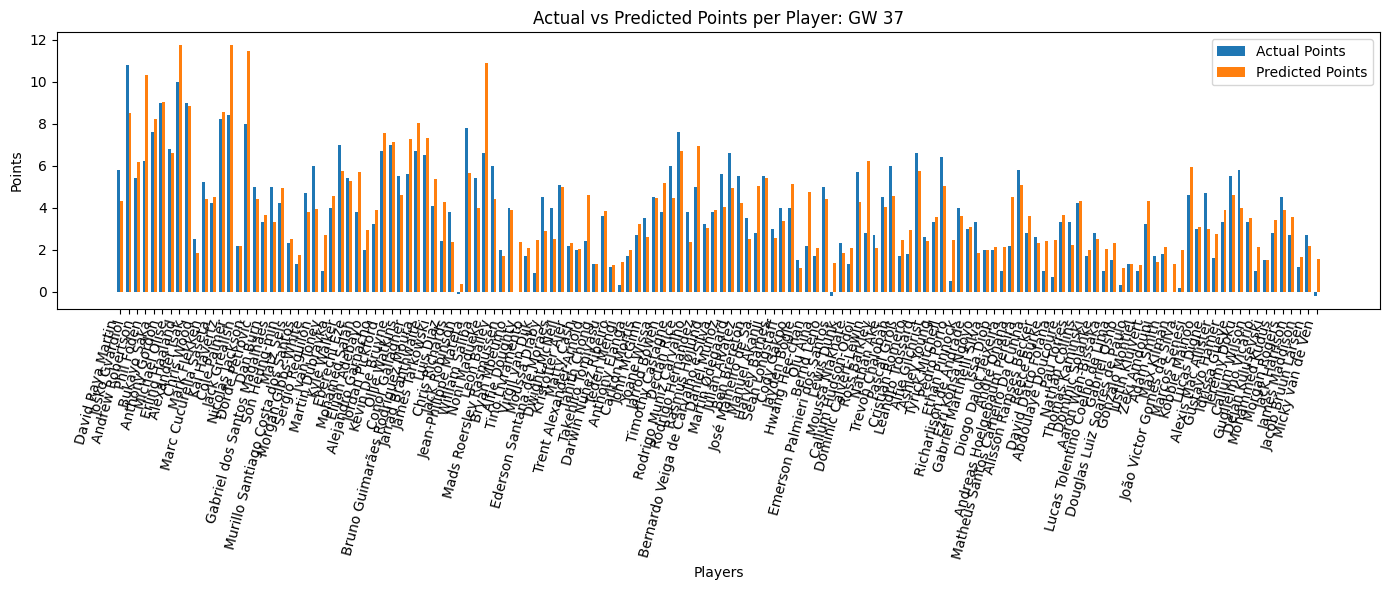

In [39]:
# Index positions for players
x = np.arange(len(Y_test_names))

# Width of each bar
width = 0.35

plt.figure(figsize=(14, 6))

# Bars
plt.bar(x - width/2, Y_test, width, label='Actual Points')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points')

# Labels & formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player: GW 37")
plt.legend()

plt.tight_layout()
plt.show()


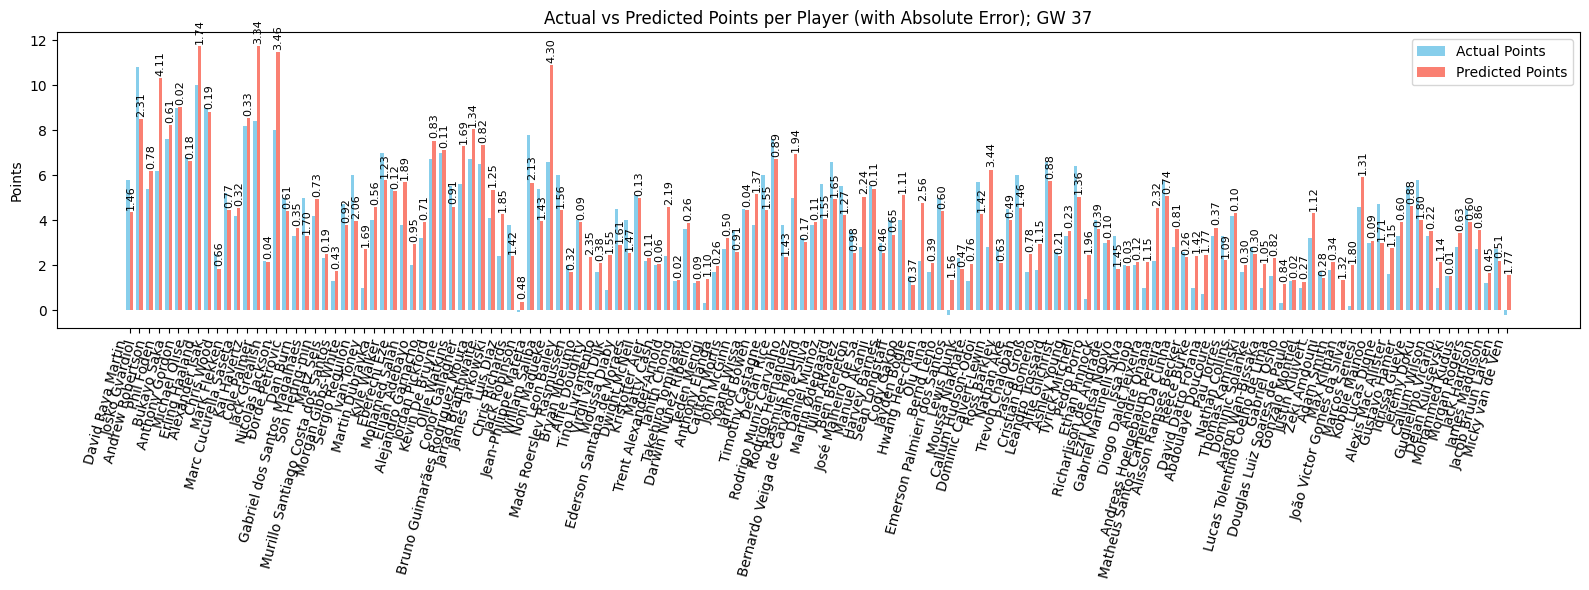

In [40]:
# Calculate absolute errors
errors = np.abs(Y_test - Y_pred)

# Index for players
x = np.arange(len(Y_test_names))
width = 0.35  # width of the bars

plt.figure(figsize=(16, 6))

# Plot Actual and Predicted points side-by-side
plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points', color='salmon')

# Annotate absolute errors on top of predicted bars
for i in range(len(Y_test_names)):
    plt.text(x[i] + width/2, Y_pred[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

# Labels and formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (with Absolute Error); GW 37")
plt.legend()
plt.tight_layout()

plt.show()


### Optimize


In [42]:
curr_data = final_df[final_df['round'] == 36].copy()
curr_data['xP_pred'] = Y_pred

players = curr_data[['fpl_id', 'fpl_name', 'team', 'value', 'position', 'xP_pred']].copy()
players['player_id'] = list(range(len(players)))

players.rename(columns={'fpl_name': 'name', 'value': 'price'}, inplace=True)
players = players.reset_index(drop=True)

selected = run_pipeline(players)

# Get total points
players_selected = curr_data[curr_data['fpl_id'].isin(selected['fpl_id'])].copy()
# players_selected = players_selected.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected['xp_rank'] = players_selected['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected['xp_rank'] == 1,  # Highest xp_preds
    players_selected['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected['score'] = players_selected['score'] * np.select(conditions, multipliers, default=1.0)
total_points = sum(players_selected['score'].values)
print(total_points, players_selected['score'].values, '--------->', players_selected['xP_pred'].values)

players_selected[['fpl_name', 'team', 'position', 'xP_pred', 'score']]

Expert selected count (11-man heuristic): 11
IRL epoch 50/200 loss=-399.0034
IRL epoch 100/200 loss=-4086.5425
IRL epoch 150/200 loss=-17014.9766
IRL epoch 200/200 loss=-46165.1055
HGAT Policy Embeddings Shape: torch.Size([142, 32])

--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---
                  name              team position  price    xP_pred  \
12         Kai Havertz           Arsenal      MID    7.5   8.531694   
5       Anthony Gordon  Newcastle United      MID    6.3   9.023186   
13         Cole Palmer   Manchester City      MID    6.2  11.744218   
43        Noni Madueke           Chelsea      MID    5.3  10.898315   
31     Jordan Pickford           Everton       GK    4.8   7.532991   
7       Erling Haaland   Manchester City      FWD   14.1  11.736516   
8       Alexander Isak  Newcastle United      FWD    8.3   8.814942   
15     Nicolas Jackson           Chelsea      FWD    6.9  11.458557   
2     Andrew Robertson         Liverpool      DEF    6.5   6.181439   
1       J

,fpl_name,team,position,xP_pred,score
4522,Joško Gvardiol,Manchester City,DEF,8.491792,6.0
4523,Andrew Robertson,Liverpool,DEF,6.181439,13.0
4526,Anthony Gordon,Newcastle United,MID,9.023186,6.0
4528,Erling Haaland,Manchester City,FWD,11.736516,31.5
4529,Alexander Isak,Newcastle United,FWD,8.814942,7.0
4533,Kai Havertz,Arsenal,MID,8.531694,5.0
4534,Cole Palmer,Manchester City,MID,11.744218,16.0
4536,Nicolas Jackson,Chelsea,FWD,11.458557,16.0
4552,Jordan Pickford,Everton,GK,7.532991,3.0
4557,Jarrad Branthwaite,Everton,DEF,7.315061,5.0


##### Rank


In [43]:
# Rank position (how many have >= your score)
fg_managers = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fgo_managers.csv')
fg_managers['points'] = fg_managers['points'].str.split(' ').str[0]
fg_managers['points'] = pd.to_numeric(fg_managers['points'], errors='coerce')
fg_managers = fg_managers[fg_managers['gameweek']== 37]
fg_managers[['points']]

position = (fg_managers['points'] > total_points).sum() + 1
# 4. Display result
total_managers = len(fg_managers)
percentile = 100 * (1-(position / total_managers))

print(total_points, total_managers)

print(f"Your predicted player’s total of {total_points} points would rank:")
print(f"→ Position: {position} out of {total_managers} managers")
print(f"→ Percentile: Top {percentile:.2f}%")


# Optional: show nearby ranks for context
nearby = fg_managers.iloc[max(position-15,0):position+2][['points','prize']].reset_index(drop=True)
print("\nClosest scores around you:")
print(nearby)

121.5 243
Your predicted player’s total of 121.5 points would rank:
→ Position: 49 out of 243 managers
→ Percentile: Top 79.84%

Closest scores around you:
    points    prize
0    126.0  R 21.51
1    126.0  R 21.51
2    126.0  R 21.51
3    126.0  R 21.51
4    126.0  R 21.51
5    123.0  R 21.51
6    123.0  R 21.51
7    122.5  R 21.51
8    122.0  R 21.51
9    122.0  R 21.51
10   122.0  R 21.51
11   122.0  R 21.51
12   122.0  R 21.51
13   122.0  R 21.51
14   121.5  R 21.51
15   121.5  R 21.51
16   121.0  R 21.51


## GW 37


### Predict


In [26]:
train_data, test_data , GW_full, X_cols = transform_data(final_df, cols, 37)
X_train_scaled, M_train_scaled, train_mask, Y_train = train_data
X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names = test_data

Data prepared. X shape: (4926, 177), M shape: (4926, 3), Y shape: (4926, 2)


In [27]:
# Model Setup
INPUT_DIM_X = X_train_scaled.shape[1]
INPUT_DIM_M = M_train_scaled.shape[1]
OUTPUT_DIM_Y = 1

model = build_affine_pnn(INPUT_DIM_X, INPUT_DIM_M, OUTPUT_DIM_Y)
model.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='mse', metrics=['mae', 'mse'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training
print("\nStarting Training...")
history = model.fit(
    [X_train_scaled, M_train_scaled], Y_train,
    epochs=10, # Increased epochs with early stopping
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Starting Training...
Epoch 1/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 11.1820 - mae: 2.6371 - mse: 10.9481 - val_loss: 4.6576 - val_mae: 1.5281 - val_mse: 4.4229
Epoch 2/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.1035 - mae: 1.4159 - mse: 3.8687 - val_loss: 3.5975 - val_mae: 1.2906 - val_mse: 3.3628
Epoch 3/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.1070 - mae: 1.2246 - mse: 2.8722 - val_loss: 3.0652 - val_mae: 1.1734 - val_mse: 2.8304
Epoch 4/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.7585 - mae: 1.1307 - mse: 2.5237 - val_loss: 2.8907 - val_mae: 1.1310 - val_mse: 2.6560
Epoch 5/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.4592 - mae: 1.0559 - mse: 2.2246 - val_loss: 2.8015 - val_mae: 1.1085 - val_mse: 2.5670
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.0594 - mae: 0.9804 - mse: 1.8250 - val_loss: 2.7286 - val_mae: 1.0897 - val_mse: 2.4944
Epoch 7/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8871 - mae: 0.

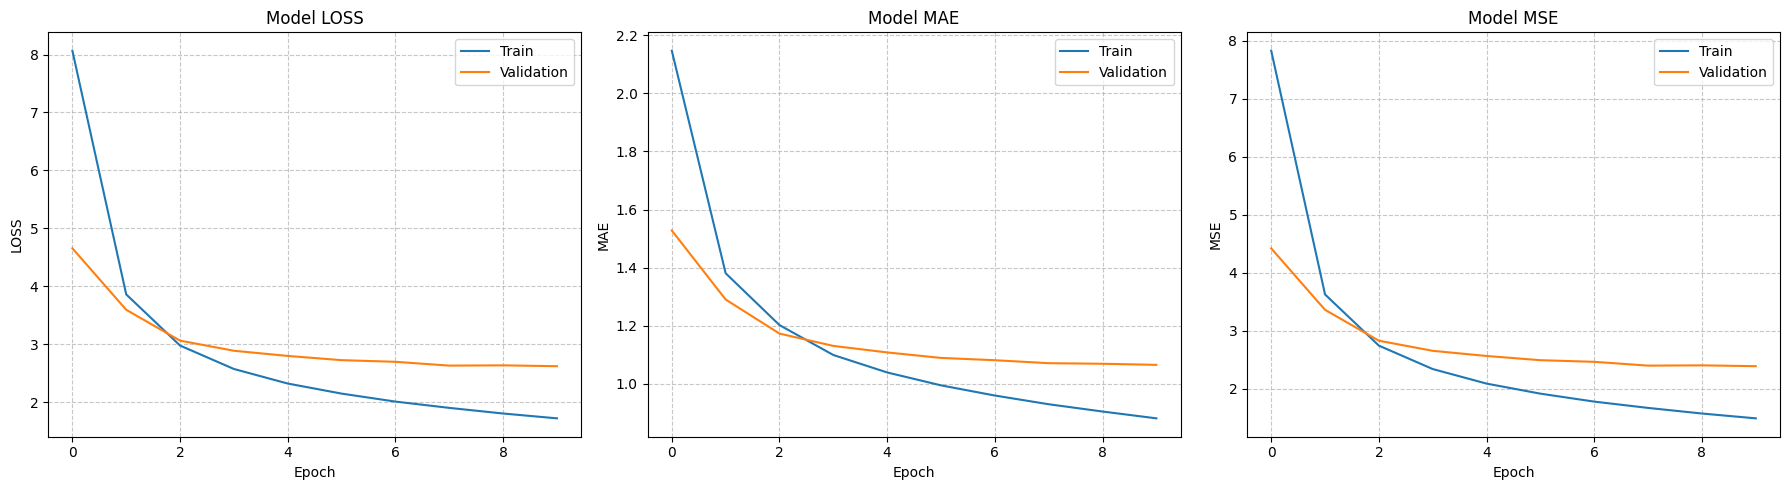


--- Final Test Set Evaluation (GW 37) ---

Evaluating test set performance...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Evaluating test set performance...{'loss': 7.177196979522705, 'mae': 1.8208918571472168, 'mse': 6.94387149810791}
R²: 0.5113154540383698
MAE: 1.8208918571472168
MSE: 6.9438714981079102
Loss: 7.1771969795227051

Generating Predictions...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

--- Results for Gameweek 37 ---
 Gameweek                 Player  Actual_xP  Predicted_xP  Team_Diff  Opp_Diff
       37         Erling Haaland       17.9         13.80       0.95     -1.22
       37             Phil Foden       14.3         11.49       1.36     -1.70
       37        Nicolas Jackson       11.0         10.71       0.22     -0.10
       37         Joško Gvardiol       23.1         10.30       1.36     -1.70
       37            Cole Palmer       10.0          9.80      -0.92     -0.14
       37        Kevin De Bruyne       15.1          9.67       1.36     -1.70
       37          Mic

In [29]:
# Plot History
plot_training_history(history)

# EVALUATE TEST SET PERFORMANCE
print("\n--- Final Test Set Evaluation (GW 37) ---")
test_results = model.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

evaluation_metrics = evaluator(model, X_test_scaled, M_test_scaled, Y_test)
print(f"Evaluating test set performance...{test_results}")
print(f"R²: {evaluation_metrics['test_R2']:.16f}")
print(f"MAE: {evaluation_metrics['test_mae']:.16f}")
print(f"MSE: {evaluation_metrics['test_mse']:.16f}")
print(f"Loss: {evaluation_metrics['test_loss']:.16f}")


# Prediction
print("\nGenerating Predictions...")
Y_pred = model.predict([X_test_scaled, M_test_scaled]).flatten()

# Results
results_df = pd.DataFrame({
    'Gameweek': GW_full[test_mask],
    'Player': Y_test_names,
    'Actual_xP': Y_test,
    'Predicted_xP': Y_pred,
    'Team_Diff': M_test_scaled[:, 1],
    'Opp_Diff': M_test_scaled[:, 0]
})

print("\n--- Results for Gameweek 37 ---")
print(results_df.sort_values(by='Predicted_xP', ascending=False).head(10).round(2).to_string(index=False))

#### Plots


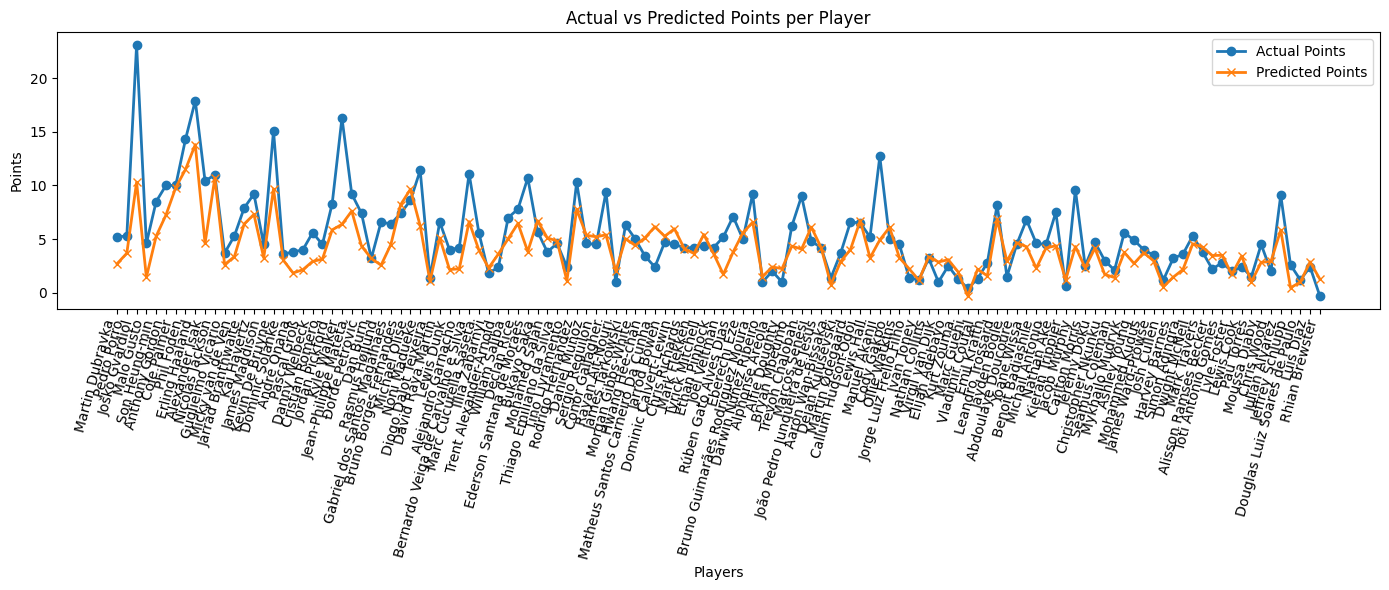

In [30]:
# Convert names to positions on x-axis
x = np.arange(len(Y_test_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, Y_pred, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player")
plt.legend()
plt.tight_layout()

plt.show()


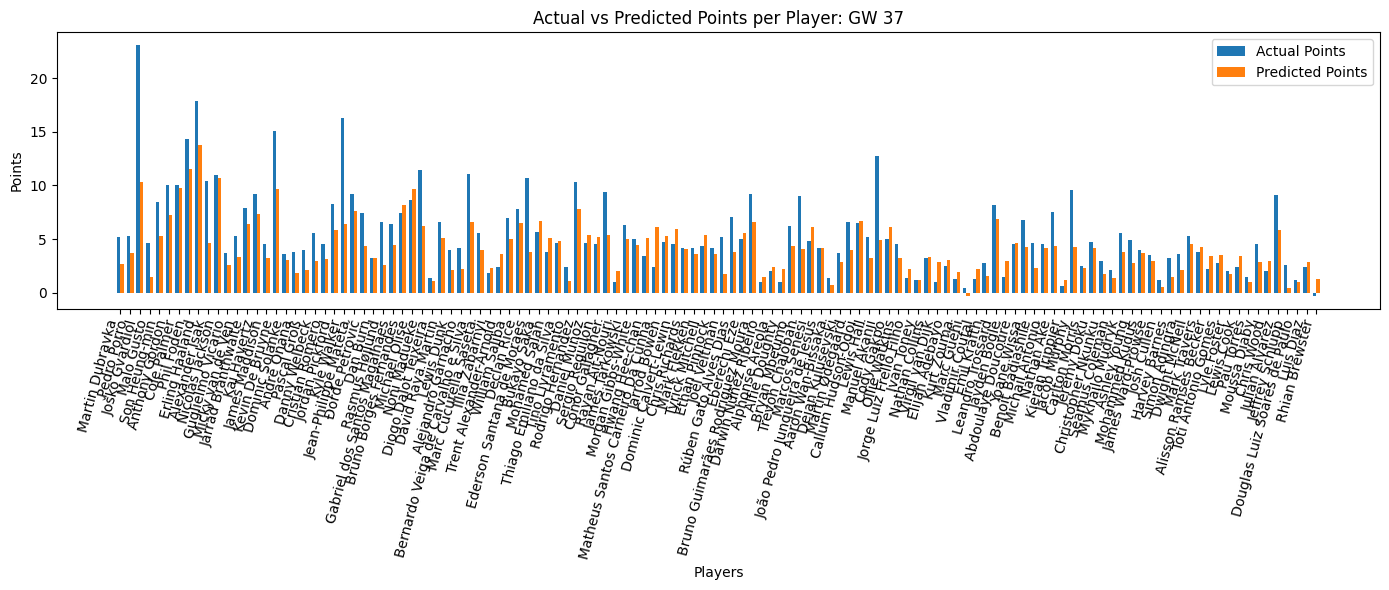

In [31]:
# Index positions for players
x = np.arange(len(Y_test_names))

# Width of each bar
width = 0.35

plt.figure(figsize=(14, 6))

# Bars
plt.bar(x - width/2, Y_test, width, label='Actual Points')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points')

# Labels & formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player: GW 37")
plt.legend()

plt.tight_layout()
plt.show()


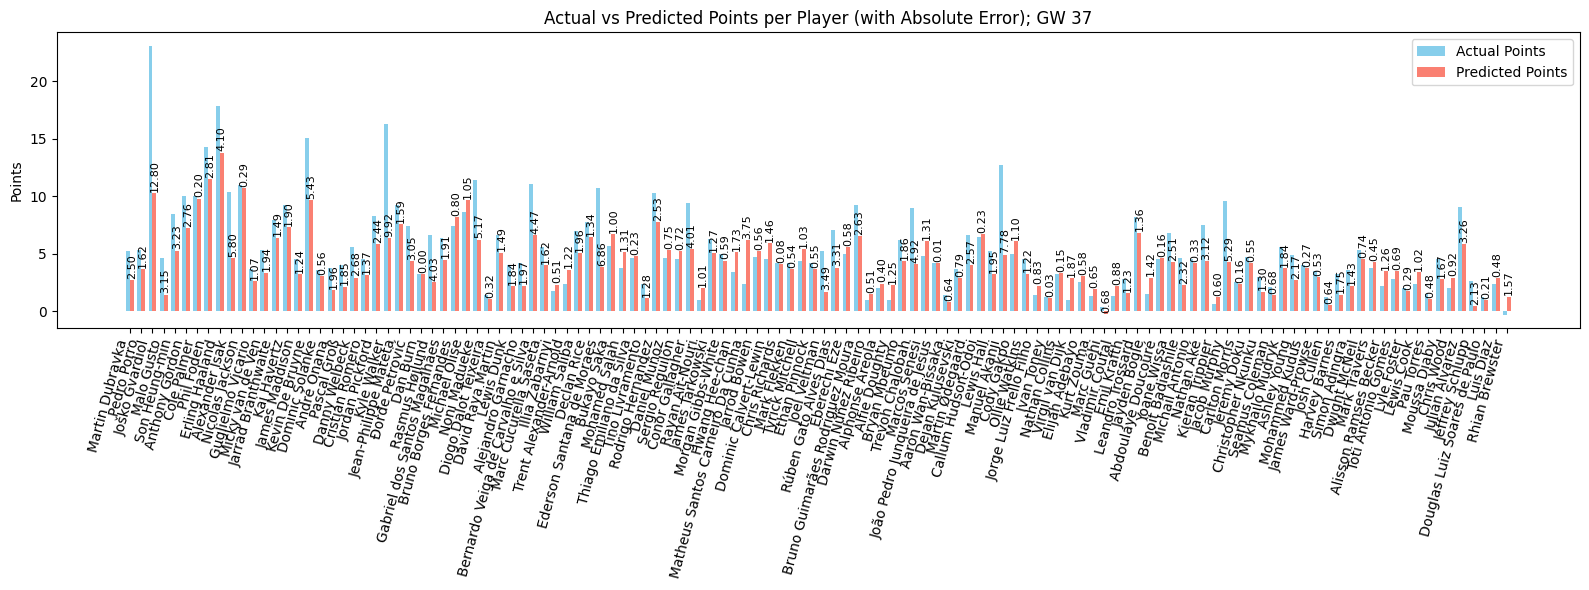

In [32]:
# Calculate absolute errors
errors = np.abs(Y_test - Y_pred)

# Index for players
x = np.arange(len(Y_test_names))
width = 0.35  # width of the bars

plt.figure(figsize=(16, 6))

# Plot Actual and Predicted points side-by-side
plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points', color='salmon')

# Annotate absolute errors on top of predicted bars
for i in range(len(Y_test_names)):
    plt.text(x[i] + width/2, Y_pred[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

# Labels and formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (with Absolute Error); GW 37")
plt.legend()
plt.tight_layout()

plt.show()


### Optimize


In [33]:
curr_data = final_df[final_df['round'] == 37].copy()
curr_data['xP_pred'] = Y_pred

players = curr_data[['fpl_id', 'fpl_name', 'team', 'value', 'position', 'xP_pred']].copy()
players['player_id'] = list(range(len(players)))

players.rename(columns={'fpl_name': 'name', 'value': 'price'}, inplace=True)
players = players.reset_index(drop=True)

selected = run_pipeline(players)

# Get total points
players_selected = curr_data[curr_data['fpl_id'].isin(selected['fpl_id'])].copy()
# players_selected = players_selected.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected['xp_rank'] = players_selected['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected['xp_rank'] == 1,  # Highest xp_preds
    players_selected['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected['score'] = players_selected['score'] * np.select(conditions, multipliers, default=1.0)
total_points = sum(players_selected['score'].values)
print(total_points, players_selected['score'].values, '--------->', players_selected['xP_pred'].values)

players_selected[['fpl_name', 'team', 'position', 'xP_pred', 'score']]

Expert selected count (11-man heuristic): 11


IRL epoch 50/200 loss=-448.2607
IRL epoch 100/200 loss=-5063.0791
IRL epoch 150/200 loss=-21817.0762
IRL epoch 200/200 loss=-60637.3320
HGAT Policy Embeddings Shape: torch.Size([124, 32])
Restricted license - for non-production use only - expires 2027-11-29

--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---
                      name               team position  price    xP_pred  \
7               Phil Foden    Manchester City      MID    8.5  11.489194   
29  Bruno Borges Fernandes  Manchester United      MID    8.5   8.201226   
14             Kai Havertz            Arsenal      MID    7.5   7.300558   
30           Michael Olise     Crystal Palace      MID    5.6   9.647214   
22         Jordan Pickford            Everton       GK    4.8   5.861188   
8           Erling Haaland    Manchester City      FWD   14.2  13.803748   
10         Nicolas Jackson            Chelsea      FWD    7.0  10.713554   
24    Jean-Philippe Mateta     Crystal Palace      FWD    5.1   7.612991   
2         

,fpl_name,team,position,xP_pred,score
4665,Joško Gvardiol,Manchester City,DEF,10.301388,27.0
4670,Phil Foden,Manchester City,MID,11.489194,16.5
4671,Erling Haaland,Manchester City,FWD,13.803748,30.0
4673,Nicolas Jackson,Chelsea,FWD,10.713554,7.0
4676,Jarrad Branthwaite,Everton,DEF,6.405490,6.0
4677,Kai Havertz,Arsenal,MID,7.300558,6.0
4685,Jordan Pickford,Everton,GK,5.861188,8.0
4687,Jean-Philippe Mateta,Crystal Palace,FWD,7.612991,9.0
4692,Bruno Borges Fernandes,Manchester United,MID,8.201226,5.0
4693,Michael Olise,Crystal Palace,MID,9.647214,12.0


##### Rank


In [34]:
# Rank position (how many have >= your score)
fg_managers = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fgo_managers.csv')
fg_managers['points'] = fg_managers['points'].str.split(' ').str[0]
fg_managers['points'] = pd.to_numeric(fg_managers['points'], errors='coerce')
fg_managers = fg_managers[fg_managers['gameweek']== 37]
fg_managers[['points']]

position = (fg_managers['points'] > total_points).sum() + 1
# 4. Display result
total_managers = len(fg_managers)
percentile = 100 * (1-(position / total_managers))

print(total_points, total_managers)

print(f"Your predicted player’s total of {total_points} points would rank:")
print(f"→ Position: {position} out of {total_managers} managers")
print(f"→ Percentile: Top {percentile:.2f}%")


# Optional: show nearby ranks for context
nearby = fg_managers.iloc[max(position-15,0):position+2][['points','prize']].reset_index(drop=True)
print("\nClosest scores around you:")
print(nearby)

130.5 243
Your predicted player’s total of 130.5 points would rank:
→ Position: 10 out of 243 managers
→ Percentile: Top 95.88%

Closest scores around you:
    points       prize
0    140.0  R 3,890.25
1    138.0  R 1,695.75
2    136.5  R 1,097.25
3    133.0    R 460.75
4    133.0    R 460.75
5    132.5    R 249.38
6    132.5    R 249.38
7    131.5     R 99.75
8    131.0     R 99.75
9    130.0     R 24.94
10   130.0     R 24.94
11   130.0     R 24.94


## GW 38


### Predict


In [44]:
train_data, test_data , GW_full, X_cols = transform_data(final_df, cols, 38)
X_train_scaled, M_train_scaled, train_mask, Y_train = train_data
X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names = test_data

Data prepared. X shape: (4926, 177), M shape: (4926, 3), Y shape: (4926, 2)


In [45]:
# Model Setup
INPUT_DIM_X = X_train_scaled.shape[1]
INPUT_DIM_M = M_train_scaled.shape[1]
OUTPUT_DIM_Y = 1

model = build_affine_pnn(INPUT_DIM_X, INPUT_DIM_M, OUTPUT_DIM_Y)
model.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='mse', metrics=['mae', 'mse'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training
print("\nStarting Training...")
history = model.fit(
    [X_train_scaled, M_train_scaled], Y_train,
    epochs=10, # Increased epochs with early stopping
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Starting Training...
Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 16.1652 - mae: 3.1522 - mse: 15.9324 - val_loss: 6.7213 - val_mae: 1.7891 - val_mse: 6.4875
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.2256 - mae: 1.4876 - mse: 3.9917 - val_loss: 4.4601 - val_mae: 1.4071 - val_mse: 4.2263
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.0827 - mae: 1.2311 - mse: 2.8488 - val_loss: 3.8925 - val_mae: 1.2884 - val_mse: 3.6588
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.5985 - mae: 1.1178 - mse: 2.3647 - val_loss: 3.6430 - val_mae: 1.2336 - val_mse: 3.4095
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.5030 - mae: 1.0933 - mse: 2.2695 - val_loss: 3.5374 - val_mae: 1.2113 - val_mse: 3.3041
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.1781 - mae: 1.0205 - mse: 1.9448 - val_loss: 3.3793 - val_mae: 1.1868 - val_mse: 3.1463
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.8812 - mae: 0.

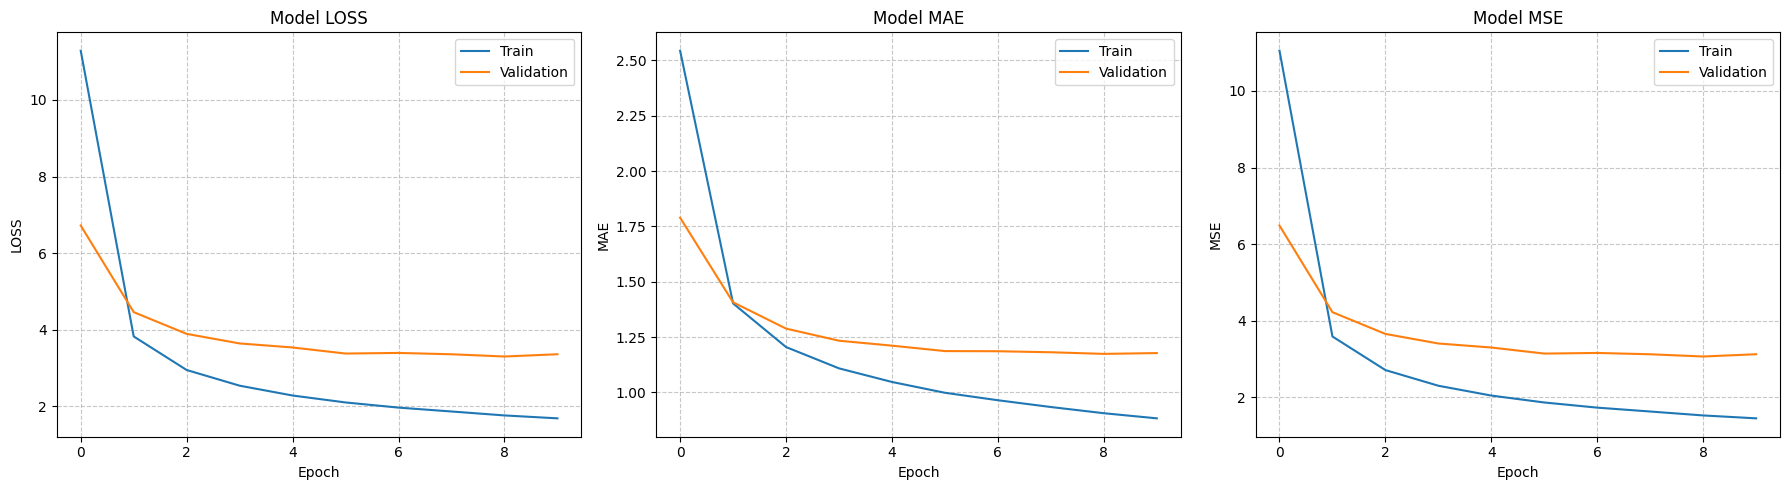


--- Final Test Set Evaluation (GW 37) ---

Evaluating test set performance...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Evaluating test set performance...{'loss': 2.425461530685425, 'mae': 1.0381990671157837, 'mse': 2.193310260772705}
R²: 0.5111776377316507
MAE: 1.0381990671157837
MSE: 2.1933102607727051
Loss: 2.4254615306854248

Generating Predictions...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

--- Results for Gameweek 37 ---
 Gameweek                             Player  Actual_xP  Predicted_xP  Team_Diff  Opp_Diff
       38                     Joško Gvardiol       10.3         14.36       1.52     -2.13
       38                         Phil Foden        8.8         14.06       1.52     -2.13
       38                     Erling Haaland        8.2         13.45       1.52     -2.13
       38    Bruno Guimarães Rodriguez Moura        7.4          9.72      -0.05      0.12
       38 Bernardo Veiga de Carvalho e Silva        6.7          9.48       1.52     -2.13
       38               Jean

In [46]:
# Plot History
plot_training_history(history)

# EVALUATE TEST SET PERFORMANCE
print("\n--- Final Test Set Evaluation (GW 37) ---")
test_results = model.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

evaluation_metrics = evaluator(model, X_test_scaled, M_test_scaled, Y_test)
print(f"Evaluating test set performance...{test_results}")
print(f"R²: {evaluation_metrics['test_R2']:.16f}")
print(f"MAE: {evaluation_metrics['test_mae']:.16f}")
print(f"MSE: {evaluation_metrics['test_mse']:.16f}")
print(f"Loss: {evaluation_metrics['test_loss']:.16f}")


# Prediction
print("\nGenerating Predictions...")
Y_pred = model.predict([X_test_scaled, M_test_scaled]).flatten()

# Results
results_df = pd.DataFrame({
    'Gameweek': GW_full[test_mask],
    'Player': Y_test_names,
    'Actual_xP': Y_test,
    'Predicted_xP': Y_pred,
    'Team_Diff': M_test_scaled[:, 1],
    'Opp_Diff': M_test_scaled[:, 0]
})

print("\n--- Results for Gameweek 37 ---")
print(results_df.sort_values(by='Predicted_xP', ascending=False).head(10).round(2).to_string(index=False))

#### Plots


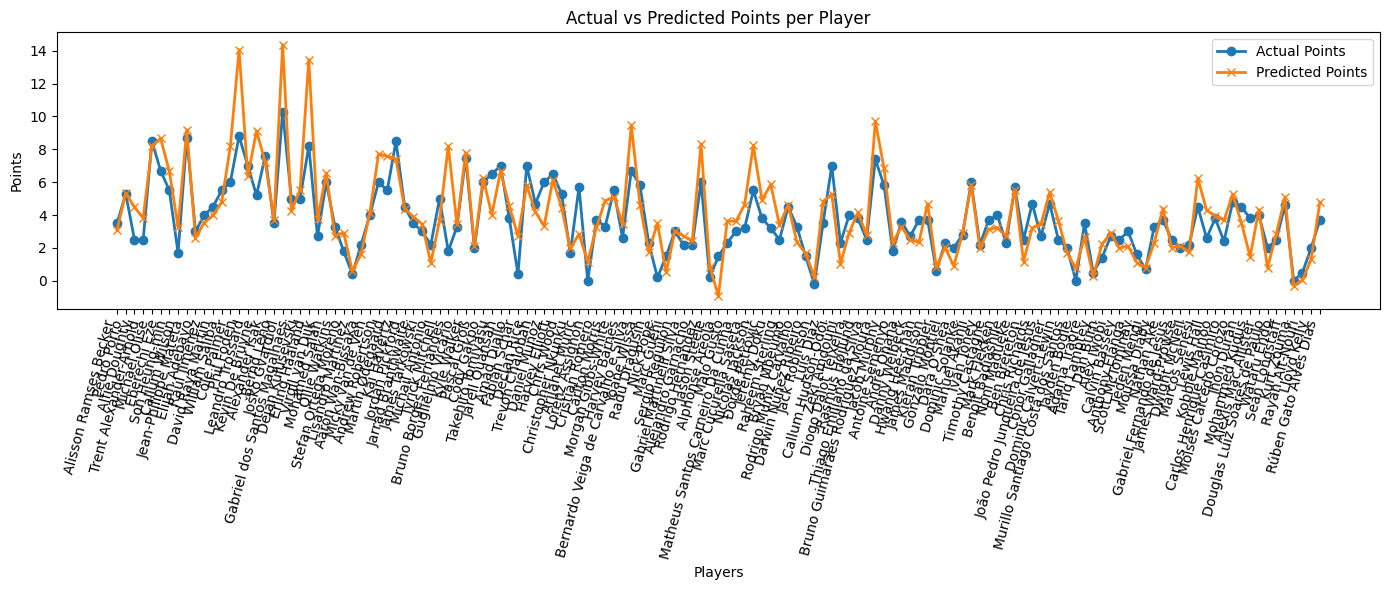

In [47]:
# Convert names to positions on x-axis
x = np.arange(len(Y_test_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, Y_pred, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player")
plt.legend()
plt.tight_layout()

plt.show()


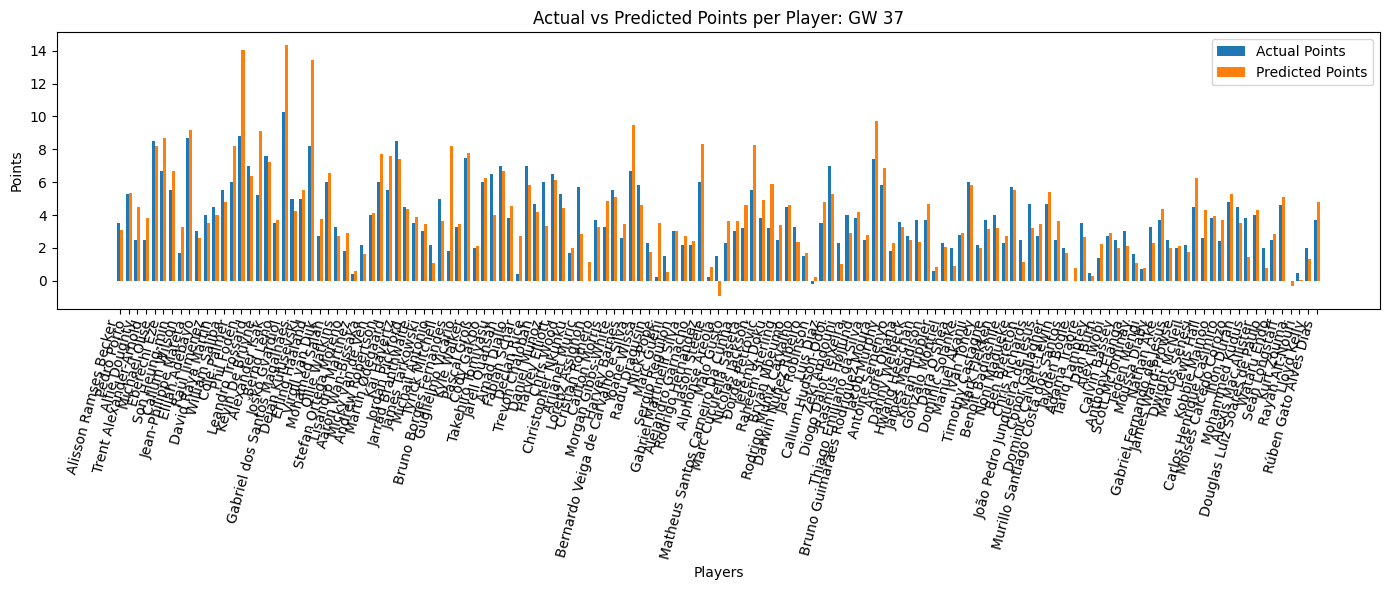

In [48]:
# Index positions for players
x = np.arange(len(Y_test_names))

# Width of each bar
width = 0.35

plt.figure(figsize=(14, 6))

# Bars
plt.bar(x - width/2, Y_test, width, label='Actual Points')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points')

# Labels & formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player: GW 37")
plt.legend()

plt.tight_layout()
plt.show()


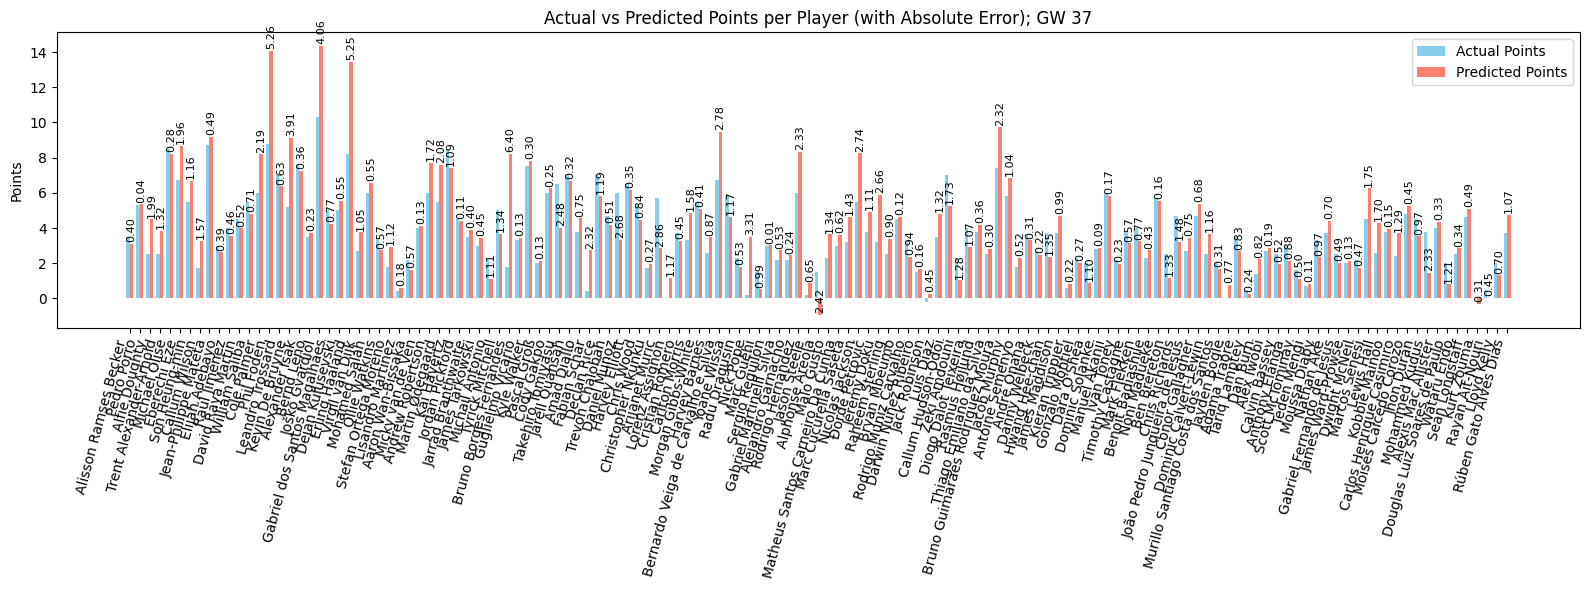

In [49]:
# Calculate absolute errors
errors = np.abs(Y_test - Y_pred)

# Index for players
x = np.arange(len(Y_test_names))
width = 0.35  # width of the bars

plt.figure(figsize=(16, 6))

# Plot Actual and Predicted points side-by-side
plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points', color='salmon')

# Annotate absolute errors on top of predicted bars
for i in range(len(Y_test_names)):
    plt.text(x[i] + width/2, Y_pred[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

# Labels and formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (with Absolute Error); GW 37")
plt.legend()
plt.tight_layout()

plt.show()


### Optimize


In [50]:
curr_data = final_df[final_df['round'] == 38].copy()
curr_data['xP_pred'] = Y_pred

players = curr_data[['fpl_id', 'fpl_name', 'team', 'value', 'position', 'xP_pred']].copy()
players['player_id'] = list(range(len(players)))

players.rename(columns={'fpl_name': 'name', 'value': 'price'}, inplace=True)
players = players.reset_index(drop=True)

selected = run_pipeline(players)

# Get total points
players_selected = curr_data[curr_data['fpl_id'].isin(selected['fpl_id'])].copy()
# players_selected = players_selected.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected['xp_rank'] = players_selected['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected['xp_rank'] == 1,  # Highest xp_preds
    players_selected['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected['score'] = players_selected['score'] * np.select(conditions, multipliers, default=1.0)
total_points = sum(players_selected['score'].values)
print(total_points, players_selected['score'].values, '--------->', players_selected['xP_pred'].values)

players_selected[['fpl_name', 'team', 'position', 'xP_pred', 'score']]

Expert selected count (11-man heuristic): 11
IRL epoch 50/200 loss=-223.0764
IRL epoch 100/200 loss=-2376.4246
IRL epoch 150/200 loss=-10026.4590
IRL epoch 200/200 loss=-27359.1465
HGAT Policy Embeddings Shape: torch.Size([139, 32])

--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---
                               name               team position  price  \
14                       Phil Foden    Manchester City      MID    8.5   
38           Bruno Borges Fernandes  Manchester United      MID    8.5   
5                      Eberechi Eze     Crystal Palace      MID    6.0   
87  Bruno Guimarães Rodriguez Moura   Newcastle United      MID    5.8   
74                   Đorđe Petrović            Chelsea       GK    4.7   
22                   Erling Haaland    Manchester City      FWD   14.3   
73                  Nicolas Jackson            Chelsea      FWD    7.0   
8              Jean-Philippe Mateta     Crystal Palace      FWD    5.1   
30                 Andrew Robertson          Liverpoo

,fpl_name,team,position,xP_pred,score
4792,Eberechi Eze,Crystal Palace,MID,8.662853,18.0
4795,Jean-Philippe Mateta,Crystal Palace,FWD,9.192301,20.0
4801,Phil Foden,Manchester City,MID,14.064911,22.5
4806,Joško Gvardiol,Manchester City,DEF,14.357425,4.0
4809,Erling Haaland,Manchester City,FWD,13.453543,2.0
4817,Andrew Robertson,Liverpool,DEF,7.718508,8.0
4825,Bruno Borges Fernandes,Manchester United,MID,8.200953,0.0
4831,Jarell Quansah,Liverpool,DEF,6.676021,15.0
4860,Nicolas Jackson,Chelsea,FWD,8.235381,2.0
4861,Đorđe Petrović,Chelsea,GK,4.914685,3.0


##### Rank


In [51]:
# Rank position (how many have >= your score)
fg_managers = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fgo_managers.csv')
fg_managers['points'] = fg_managers['points'].str.split(' ').str[0]
fg_managers['points'] = pd.to_numeric(fg_managers['points'], errors='coerce')
fg_managers = fg_managers[fg_managers['gameweek']== 37]
fg_managers[['points']]

position = (fg_managers['points'] > total_points).sum() + 1
# 4. Display result
total_managers = len(fg_managers)
percentile = 100 * (1-(position / total_managers))

print(total_points, total_managers)

print(f"Your predicted player’s total of {total_points} points would rank:")
print(f"→ Position: {position} out of {total_managers} managers")
print(f"→ Percentile: Top {percentile:.2f}%")


# Optional: show nearby ranks for context
nearby = fg_managers.iloc[max(position-15,0):position+2][['points','prize']].reset_index(drop=True)
print("\nClosest scores around you:")
print(nearby)

110.5 243
Your predicted player’s total of 110.5 points would rank:
→ Position: 124 out of 243 managers
→ Percentile: Top 48.97%

Closest scores around you:
    points prize
0    112.5   NaN
1    112.5   NaN
2    112.5   NaN
3    112.0   NaN
4    112.0   NaN
5    112.0   NaN
6    111.5   NaN
7    111.5   NaN
8    111.0   NaN
9    111.0   NaN
10   111.0   NaN
11   111.0   NaN
12   111.0   NaN
13   111.0   NaN
14   110.5   NaN
15   110.5   NaN
16   109.5   NaN
